In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-filter',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_sim',
        '--data_nsample', '500',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.800442, valid=0.222251, test=0.228301
	validation loss decreased (inf -> 0.222251), saving model ...
	epoch 2 losses: train=0.828763, valid=0.065570, test=0.067028
	validation loss decreased (0.222251 -> 0.065570), saving model ...
	epoch 3 losses: train=0.690544, valid=0.061851, test=0.063227
	validation loss decreased (0.065570 -> 0.061851), saving model ...
	epoch 4 losses: train=0.659056, valid=0.058365, test=0.059955
	validation loss decreased (0.061851 -> 0.058365), saving model ...
	epoch 5 losses: train=0.651581, valid=0.057490, test=0.059111
	validation loss decreased (0.058365 -> 0.057490), saving model ...
	epoch 6 losses: train=0.649381, valid=0.057099, test=0.058811
	validation loss decreased (0.057490 -> 0.057099), saving model ...
	epoch 7 losses: train=0.647701, valid=0.058645, test=0.060422
	early stopping counter: 1 out of 10
	epoch 8 losses: train=0.598427, valid=0.063435, test=0.067337
	early stopping counter: 2

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

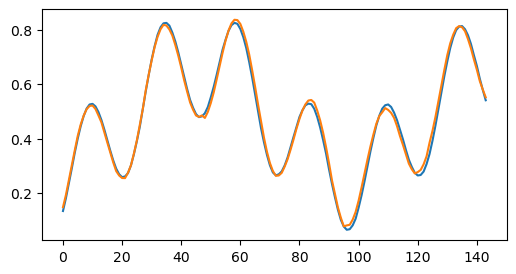

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break